# MNIST Experiment: B-LRP Explanations
This notebook computes B-LRP explanations for the MNIST data using the LRP-Epsilon rule.


In [7]:
#!pip install -r requirements.txt
#imports
import torch
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.ticker as ticker
import copy

from torch import nn
import torchvision
import torchvision.transforms as transforms
import torch.nn.functional as F

from tqdm import tqdm

import seaborn as sns

Defaulting to user installation because normal site-packages is not writeable
  Using cached numpy-1.18.5.zip (5.4 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [28 lines of output]
      Running from numpy source directory.
      <string>:461: UserWarning: Unrecognized setuptools command, proceeding with generating Cython sources and expanding templates
      Traceback (most recent call last):
        File "C:\Users\Gebruiker\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\Gebruiker\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
   

# Model Creation
The following text was written by the original authors, see the citation in the report for more information.

First, we import a checkpoint with a trained LeNet model. We change standard Dropout layers for custom ones in order to be able to memorize, which particular neurons were dropped out. This is necessary in order to perform the standard LRP procedure afterwards.

In [2]:
class MyDropout(nn.Module):                                                        #custom Dropout layer for saving the parameters, to be used in LRP
    def __init__(self, p=0.5):
        super(MyDropout, self).__init__()
        self.p = p
        self.seed = 0
    
    def forward(self, input, freeze = False):
        if not self.training:                                                      # if model.eval(), don't apply dropout
            return input

        if not freeze:                                                             # if freeze == False, generate new random seed
            q=np.random.randint(10000000, size = 1)[0]                             # if freeze == True , use random seed from previous run (used in LRP)
            self.seed = q
        
        torch.manual_seed(self.seed)   
        return torch.nn.functional.dropout2d(input, p=self.p)

class LeNet(nn.Module):
    def __init__(self, droprate=0.5):
        super(LeNet, self).__init__()
        self.model = nn.Sequential()
        self.model.add_module('conv1', nn.Conv2d(1, 24, 5))
        self.model.add_module('relu1', nn.ReLU())
        self.model.add_module('maxpool1', nn.MaxPool2d(2))
        self.model.add_module('conv2', nn.Conv2d(24, 48, kernel_size=5))
        self.model.add_module('relu2', nn.ReLU())
        self.model.add_module('dropout2', MyDropout())
        self.model.add_module('maxpool2', nn.MaxPool2d(2))
        self.model.add_module('flatten', nn.Flatten())
        self.model.add_module('dense3', nn.Linear(48*5*5, 240))
        self.model.add_module('relu3', nn.ReLU())
        self.model.add_module('dropout3', MyDropout())
        self.model.add_module('final', nn.Linear(240, 10))
        
    def forward(self, x):
        return self.model(x)

model = LeNet()
model.load_state_dict(torch.load('mnist_lenet.ckpt', map_location=torch.device('cpu')))                           #load model from file

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

cpu


We then download the test data of the MNIST dataset:

In [3]:
transform=transforms.Compose([
                           transforms.Resize((32, 32)),
                           transforms.ToTensor(),
                           transforms.Normalize((0.1307,), (0.3081,))
                       ])

testset = torchvision.datasets.MNIST(root='./data', train=False,                #load MNIST data
                                       download=True, transform=transform)

# Model Training

In [4]:
# --------------------------------------------------------------
# LRP Epsilon rule
# --------------------------------------------------------------

# More information at http://www.heatmapping.org/tutorial/

def LRP_epsilon(image, class_id, model, dropout = True, verbose = False, device = 'cpu', epsilon = 1e-9):


    # image:        Original Image,
    # class_id:     Index of a true class,
    # model:        Neural Network,
    # dropout:      If set True -- run LRP-Epsilon on a sample from posterior, else run Standard LRP-Epsilon,
    # verbose:      If set True -- print top 3 output scores,
    # device:       Default device,
    # epsilon:      Value of epsilon,
   
    if not dropout:
        model.eval()
    else:
        model.train()
    model.to(device)

    X = image.view([1,1,32,32]).to(device)
    layers = list(model.modules())[2:]
    L = len(layers)


    A = [X]+[None]*L
    with torch.no_grad():
      for l in range(L): A[l+1] = layers[l].forward(A[l]).to(device)
    
    scores = np.array(A[-1].data.view(-1).cpu())
    ind = np.argsort(-scores)
    
    if verbose:
        for i in ind[:3]:
            print('New instance:')
            print('%20s (%3d): %6.3f'%(imgclasses[i][:20],i,scores[i]))

    T = torch.FloatTensor((1.*(np.arange(10)==class_id).reshape(A[-1].shape))).to(device)
    R = [None] * L + [(A[-1]*T)]

    for l in range(0,L)[::-1]:
        A[l] = A[l].requires_grad_(True)
        rho = lambda p: p;                       incr = lambda z: z + epsilon

        if isinstance(layers[l],torch.nn.MaxPool2d): layers[l] = torch.nn.AvgPool2d(2)
        
        if isinstance(layers[l],torch.nn.Conv2d) or \
           isinstance(layers[l],torch.nn.AvgPool2d) or \
           isinstance(layers[l],torch.nn.Linear) or \
           isinstance(layers[l],torch.nn.Flatten):

            z = incr(newlayer(layers[l],rho).forward(A[l]))        # step 1
            s = (R[l+1]/z).data                                    # step 2
            (z*s).sum().backward(); c = A[l].grad                  # step 3
            R[l] = (A[l]*c).data                                   # step 4
            
        else:
            if not dropout:
              R[l] = R[l+1]
            else:
              if isinstance(layers[l],MyDropout):
                  incr = lambda z: z + epsilon
                  z = incr(layers[l].forward(A[l], freeze = True))       # step 1: we freeze random state so we can remember which neurons were dropped
                  s = (R[l+1]/z).data                                    # step 2
                  (z*s).sum().backward(); c = A[l].grad                  # step 3
                  R[l] = (A[l]*c).data                                   # step 4
              else:
                  R[l] = R[l+1]

    return R[0].data


# --------------------------------------------------------------
# Clone a layer and pass its parameters through the function g
# --------------------------------------------------------------

def newlayer(layer,g):

    layer = copy.deepcopy(layer)

    try: layer.weight = nn.Parameter(g(layer.weight))
    except AttributeError: pass

    try: layer.bias   = nn.Parameter(g(layer.bias))
    except AttributeError: pass

    return layer

# --------------------------------------------------------------
# Function for MinMax Normalisation of Relevances
# --------------------------------------------------------------

def normalise_relevance(relevance_matrix):
    a = relevance_matrix.min()
    b = relevance_matrix.max()
    
    if (a == 0.) & (b == 0.):
        return relevance_matrix
    if (a > 0.):
      return (relevance_matrix >0.)*relevance_matrix/b
    if (b < 0.):
      return - (relevance_matrix <=0.)*relevance_matrix/a
    
    return (relevance_matrix >0.)*relevance_matrix/b  - (relevance_matrix <=0.)*relevance_matrix/a

## B-LRP: Visualization
With the following cell we compute samples from the LRP distribution for three random selected images. Therefore, we sample *N_MC* times from the posterior distribution. This allows us in the next step to compute the percentile estimations.



In [5]:
N_MC = 100                                              # Number of times we sample the posterior to get an estimation for percentiles in B-LRP
samples = np.random.choice(10000, 3)                    # Randomly sample 3 images from testset

LRPs = torch.zeros([len(samples), N_MC, 32, 32])
Standard_LRPs = torch.zeros([len(samples), 32, 32])

counter = 0
for q in samples:
  for i in tqdm(range(N_MC)):
    LRPs[counter][i] = LRP_epsilon(testset[q][0].to(device), testset[q][1], model, dropout = True)[0][0].data
  Standard_LRPs[counter] = LRP_epsilon(testset[q][0].to(device), testset[q][1], model, dropout = False)[0][0].data
  counter = counter + 1

  0%|          | 0/100 [00:00<?, ?it/s]C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_10396\112722345.py:16: UserWarning: dropout2d: Received a 2-D input to dropout2d, which is deprecated and will result in an error in a future release. To retain the behavior and silence this warning, please use dropout instead. Note that dropout2d exists to provide channel-wise dropout on inputs with 2 spatial dimensions, a channel dimension, and an optional batch dimension (i.e. 3D or 4D inputs).
  return torch.nn.functional.dropout2d(input, p=self.p)
C:\Users\Gebruiker\AppData\Local\Temp\ipykernel_10396\304668003.py:33: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  scores = np.array(A[-1].data.view(-1).cpu())
100%|██████████| 100/100 [00:01<0

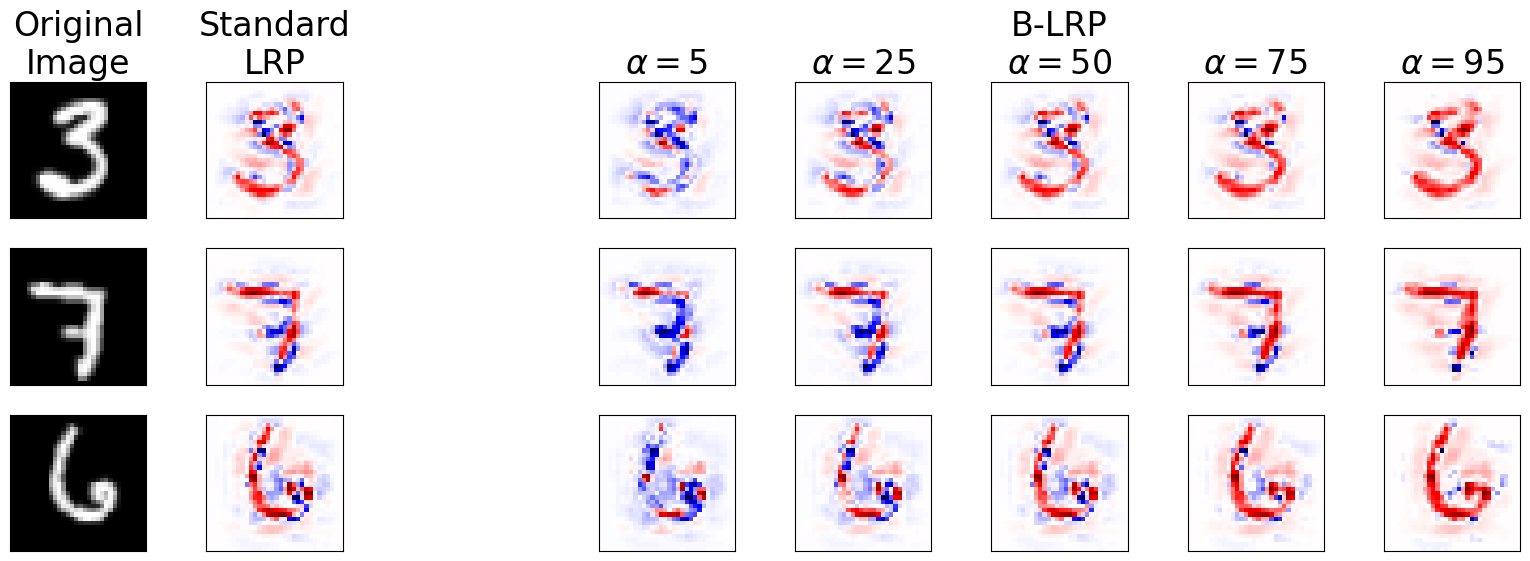

In [6]:
I = len(samples)
alphas = [ 5, 25, 50, 75, 95 ]

matplotlib.rcParams.update({'font.size': 20})
fig, ax = plt.subplots(I, 8, figsize=(16,2 * I))

cols = ['Original\nImage', 'Standard\nLRP', '', r'$\alpha = 5$', r'$\alpha = 25$', 'B-LRP\n'+r'$\alpha = 50$', r'$\alpha = 75$', r'$\alpha = 95$']

for axe, col in zip(ax[0], cols):
    axe.set_title(col)

for i in range(I):
  img = testset[samples[i]][0][0]
  ax[i][0].imshow(img.cpu(), cmap='gray')
  ax[i][0].xaxis.set_major_locator(plt.NullLocator())
  ax[i][0].yaxis.set_major_locator(plt.NullLocator())
  
  ax[i][1].imshow(normalise_relevance(Standard_LRPs[i].cpu()), cmap = 'seismic')
  ax[i][1].xaxis.set_major_locator(plt.NullLocator())
  ax[i][1].yaxis.set_major_locator(plt.NullLocator())

  ax[i][2].set_axis_off()

  LRP_ALPHAs = torch.zeros([len(alphas), 32,32])

  for j in range(len(alphas)):
      LRP_ALPHAs[j] = torch.tensor(np.percentile(LRPs[i].cpu().reshape([N_MC, - 1]).numpy(), alphas[j], axis = 0).reshape([32,32]))
      ax[i][3+j].imshow(normalise_relevance(LRP_ALPHAs[j]), vmin = -1, vmax = 1, cmap = 'seismic')
      ax[i][3+j].xaxis.set_major_locator(plt.NullLocator())
      ax[i][3+j].yaxis.set_major_locator(plt.NullLocator())

plt.tight_layout()
plt.show()